<a href="https://colab.research.google.com/github/Chandu0444/Machine_learning/blob/main/capstone_project_3(walmart_prophet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

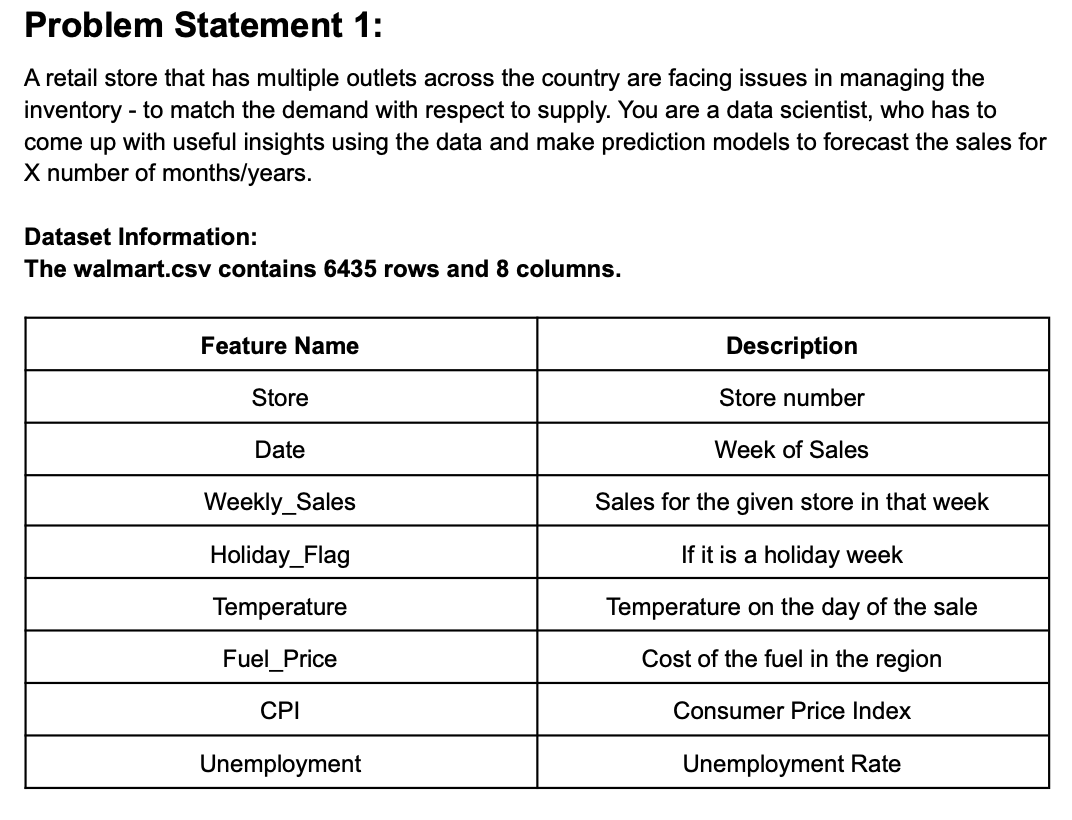

1. Using the above data, come up with useful insights that can be used by each of
the stores to improve in various areas.
2. Forecast the sales for each store for the next 12 weeks.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
data = pd.read_csv('/content/Walmart DataSet.csv')

In [87]:
data.shape

(6435, 8)

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [89]:
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [90]:
data.duplicated().sum()

np.int64(0)

In [91]:
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [92]:
data['Store'].values

array([ 1,  1,  1, ..., 45, 45, 45])

In [93]:
data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending = False)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


In [94]:
#which stores are growing
data.groupby('Date')['Weekly_Sales'].sum().sort_values(ascending= False)

,Weekly_Sales
Date,
24-12-2010,80931415.60
23-12-2011,76998241.31
25-11-2011,66593605.26
26-11-2010,65821003.24
17-12-2010,61820799.85
...,...
14-01-2011,40673678.04
21-01-2011,40654648.03
31-12-2010,40432519.00


In [95]:
#temperature impact
data[['Weekly_Sales','Temperature']].corr()

,Weekly_Sales,Temperature
Weekly_Sales,1.00000,-0.06381
Temperature,-0.06381,1.00000


In [96]:
#holiday impact
data[['Weekly_Sales','Holiday_Flag']].corr()

,Weekly_Sales,Holiday_Flag
Weekly_Sales,1.000000,0.036891
Holiday_Flag,0.036891,1.000000


In [97]:
data.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [98]:
#Fuel price impact
data[['Weekly_Sales','Fuel_Price']].corr()

,Weekly_Sales,Fuel_Price
Weekly_Sales,1.000000,0.009464
Fuel_Price,0.009464,1.000000


In [99]:
# unemployment impact
data[['Weekly_Sales','Unemployment']].corr()

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.106176
Unemployment,-0.106176,1.000000


Change the data type of date

In [100]:
data['Date'] = pd.to_datetime(data['Date'],format='%d-%m-%Y')

In [104]:
#!pip install --upgrade pip
#!pip install prophet

In [ ]:
forecasting = data[['Date','Weekly_Sales']]
forecasting.rename(columns = {'Date':'ds','Weekly_Sales':'y'},inplace=True)
from prophet import Prophet
model = Prophet()
model.fit(forecasting)
future = model.make_future_dataframe(periods = 12, freq = 'W')
forecasted = model.predict(future)
forecasted_final = forecasted[['ds','yhat']]
forecasted_final['yhat'] = forecasted_final['yhat'].astype(int)
forecasted_final

In [114]:
forecasting = data[['Date','Weekly_Sales']]
forecasting

,Date,Weekly_Sales
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68
...,...,...
6430,2012-09-28,713173.95
6431,2012-10-05,733455.07
6432,2012-10-12,734464.36
6433,2012-10-19,718125.53


#now we are using prophet so before predicting future the columns names should be passed as date as 'ds' and target col as 'y'

In [128]:
forecasting.rename(columns = {'Date':'ds','Weekly_Sales':'y'},inplace=True)
forecasting

/tmp/ipykernel_10299/439562756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecasting.rename(columns = {'Date':'ds','Weekly_Sales':'y'},inplace=True)


,ds,y
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68
...,...,...
6430,2012-09-28,713173.95
6431,2012-10-05,733455.07
6432,2012-10-12,734464.36
6433,2012-10-19,718125.53


#Model building

In [116]:
from prophet import Prophet
model = Prophet()
model.fit(forecasting)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


#Forecating

In [118]:
future = model.make_future_dataframe(periods = 12, freq = 'W')
future

,ds
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
150,2012-12-16
151,2012-12-23
152,2012-12-30
153,2013-01-06


In [132]:
forecasted = model.predict(future)
forecasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,787511.661186,6.857603e+05,8.793492e+05,787511.661186,787511.661186,-465.740701,-465.740701,-465.740701,-465.740701,-465.740701,-465.740701,0.0,0.0,0.0,7.870459e+05
1,2010-02-12,787605.956883,6.971987e+05,9.018061e+05,787605.956883,787605.956883,9445.042951,9445.042951,9445.042951,9445.042951,9445.042951,9445.042951,0.0,0.0,0.0,7.970510e+05
2,2010-02-19,787700.252580,6.707196e+05,8.805347e+05,787700.252580,787700.252580,-19840.029822,-19840.029822,-19840.029822,-19840.029822,-19840.029822,-19840.029822,0.0,0.0,0.0,7.678602e+05
3,2010-02-26,787794.548276,6.444086e+05,8.482178e+05,787794.548276,787794.548276,-37630.530723,-37630.530723,-37630.530723,-37630.530723,-37630.530723,-37630.530723,0.0,0.0,0.0,7.501640e+05
4,2010-03-05,787888.843973,6.505373e+05,8.435530e+05,787888.843973,787888.843973,-31606.236354,-31606.236354,-31606.236354,-31606.236354,-31606.236354,-31606.236354,0.0,0.0,0.0,7.562826e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,2012-12-16,801589.474845,1.112941e+06,1.317170e+06,801589.470997,801589.478553,417815.423717,417815.423717,417815.423717,417815.423717,417815.423717,417815.423717,0.0,0.0,0.0,1.219405e+06
151,2012-12-23,801683.778230,1.102739e+06,1.310123e+06,801683.773612,801683.782598,399862.273439,399862.273439,399862.273439,399862.273439,399862.273439,399862.273439,0.0,0.0,0.0,1.201546e+06
152,2012-12-30,801778.081616,9.218560e+05,1.119666e+06,801778.076253,801778.086713,221135.251512,221135.251512,221135.251512,221135.251512,221135.251512,221135.251512,0.0,0.0,0.0,1.022913e+06
153,2013-01-06,801872.385001,6.747770e+05,8.769736e+05,801872.378756,801872.390978,-25693.112152,-25693.112152,-25693.112152,-25693.112152,-25693.112152,-25693.112152,0.0,0.0,0.0,7.761793e+05


In [137]:
forecasted_final = forecasted[['ds','yhat']].tail(12)
forecasted_final['yhat'] = forecasted_final['yhat'].astype(int)
forecasted_final

,ds,yhat
143,2012-10-28,748286
144,2012-11-04,795545
145,2012-11-11,846786
146,2012-11-18,875139
147,2012-11-25,901509
148,2012-12-02,976661
149,2012-12-09,1108352
150,2012-12-16,1219404
151,2012-12-23,1201546
152,2012-12-30,1022913
